<a href="https://colab.research.google.com/github/RecursionAndIteration/AIcourse/blob/main/Konwolucyjne_sieci_neuronowe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

#Wycięcie 10 przykładów ze zbioru testowego
images_to_check = x_test[:10]
labels_to_check = y_test[:10]

x_test = x_test[10:]
y_test = y_test[10:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import time
start = time.time()


model = Sequential([
    #Pierwszy blok konwolucyjny
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    #Drugi blok konwolucyjny
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    #Blok gęsty
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])


history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_test, y_test))


loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Strata: {loss:.4f}, Dokładność: {accuracy:.4f}")

end = time.time()  # czas końca

print(f"Czas wykonania: {end - start:.2f} sekundy")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.8900 - loss: 0.3663 - val_accuracy: 0.9861 - val_loss: 0.0406
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9730 - loss: 0.0899 - val_accuracy: 0.9889 - val_loss: 0.0330
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9789 - loss: 0.0678 - val_accuracy: 0.9788 - val_loss: 0.3332
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9813 - loss: 0.0622 - val_accuracy: 0.9901 - val_loss: 0.0342
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9816 - loss: 0.0577 - val_accuracy: 0.9927 - val_loss: 0.0233
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9914 - val_loss: 0.0264
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.9930 - val_loss: 0.0224
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9869 - loss: 0.0

In [ ]:
import tensorflow as tf
print("Czy GPU jest dostępne:", tf.config.list_physical_devices('GPU'))

Czy GPU jest dostępne: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



--- Sprawdzenie 10 grafik z wyciętego zbioru testowego ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step


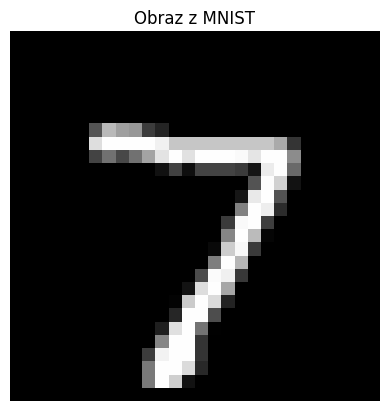

Rozpoznana cyfra: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


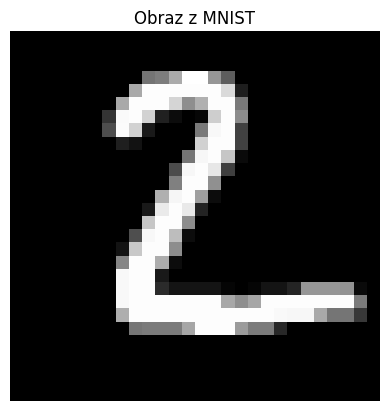

Rozpoznana cyfra: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


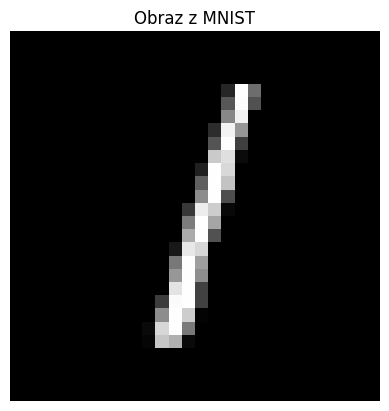

Rozpoznana cyfra: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


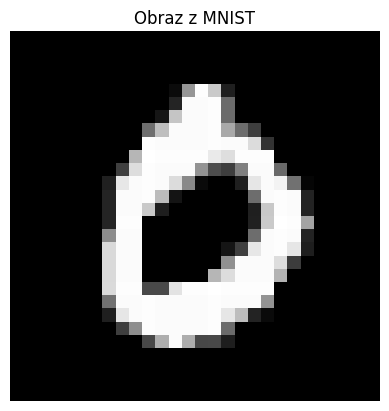

Rozpoznana cyfra: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


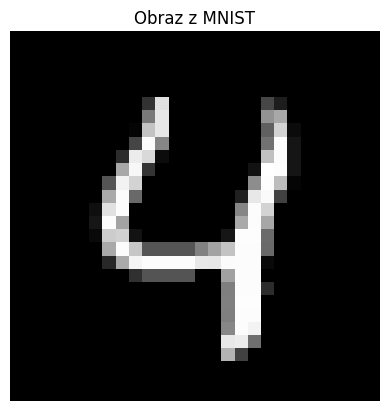

Rozpoznana cyfra: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


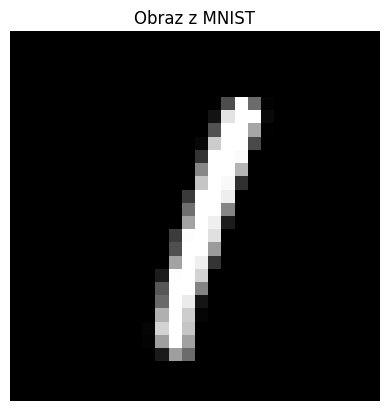

Rozpoznana cyfra: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


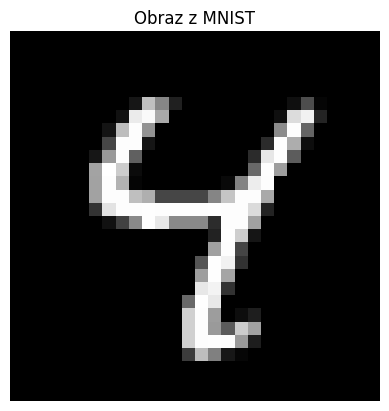

Rozpoznana cyfra: 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


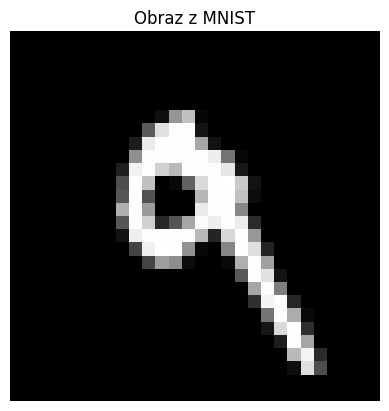

Rozpoznana cyfra: 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


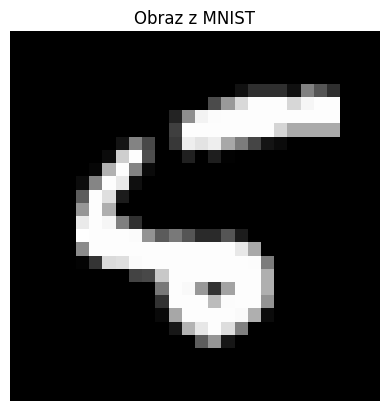

Rozpoznana cyfra: 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


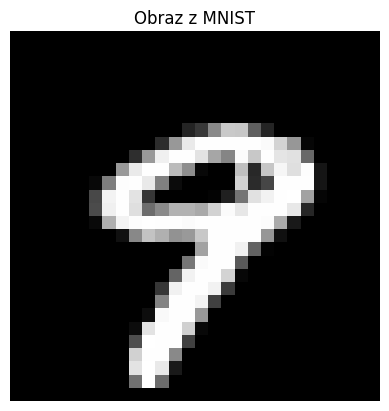

Rozpoznana cyfra: 9


In [ ]:
#Wyświetlanie sklasyfikowanej etykiety
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

# Testowanie grafik z folderu
for path in Path("testowe").rglob("*.png"):
    image = Image.open(path).convert('L')
    image = ImageOps.invert(image)
    image = image.resize((28, 28))
    image = np.array(image).reshape(1, 28, 28, 1) / 255.0

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title('Przetworzony obraz')
    plt.axis('off')
    plt.show()

    prediction = model.predict(image)[0]
    predicted_digit = np.argmax(prediction)

    print(f"Rozpoznana cyfra: {predicted_digit}")

# Testowanie 10 wyciętych obrazów z MNIST
print("\n--- Sprawdzenie 10 grafik z wyciętego zbioru testowego ---")
for i, image in enumerate(images_to_check):
    image_input = image.reshape(1, 28, 28, 1)
    prediction = model.predict(image_input)[0]

    predicted_digit = np.argmax(prediction)
    true_label = np.argmax(labels_to_check[i])

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Obraz z MNIST")
    plt.axis('off')
    plt.show()

    print(f"Rozpoznana cyfra: {predicted_digit}")


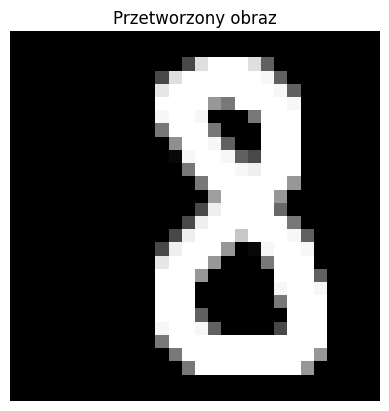

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 8, Prawdopodobieństwo: 1.0000
2. Cyfra: 3, Prawdopodobieństwo: 0.0000
3. Cyfra: 2, Prawdopodobieństwo: 0.0000


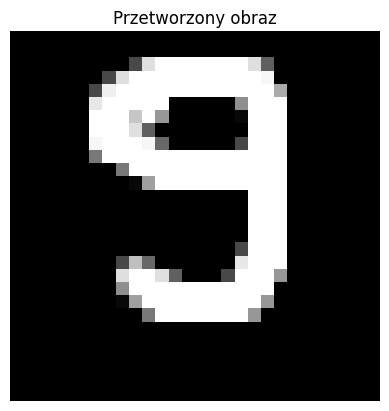

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 3, Prawdopodobieństwo: 0.7276
2. Cyfra: 9, Prawdopodobieństwo: 0.1109
3. Cyfra: 5, Prawdopodobieństwo: 0.0761


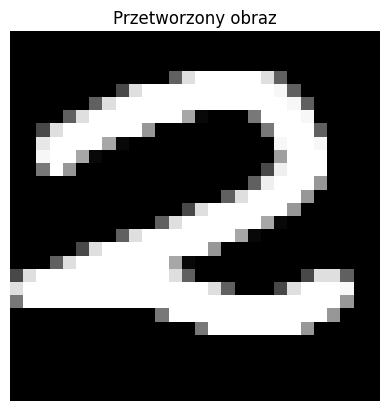

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 2, Prawdopodobieństwo: 1.0000
2. Cyfra: 8, Prawdopodobieństwo: 0.0000
3. Cyfra: 3, Prawdopodobieństwo: 0.0000


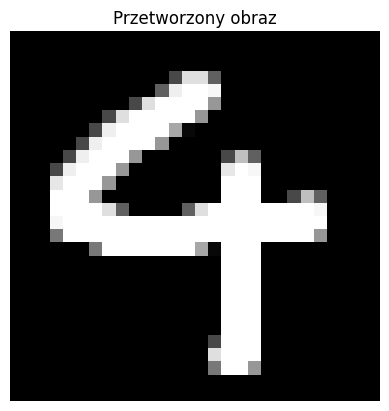

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 9, Prawdopodobieństwo: 0.8167
2. Cyfra: 4, Prawdopodobieństwo: 0.1761
3. Cyfra: 8, Prawdopodobieństwo: 0.0071


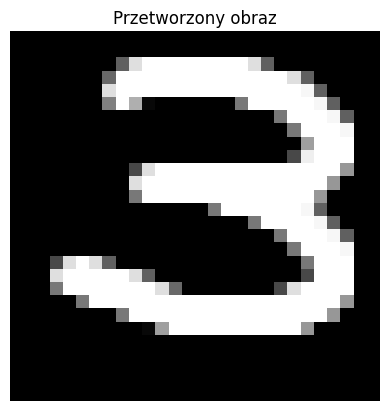

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 3, Prawdopodobieństwo: 0.9863
2. Cyfra: 2, Prawdopodobieństwo: 0.0122
3. Cyfra: 5, Prawdopodobieństwo: 0.0011


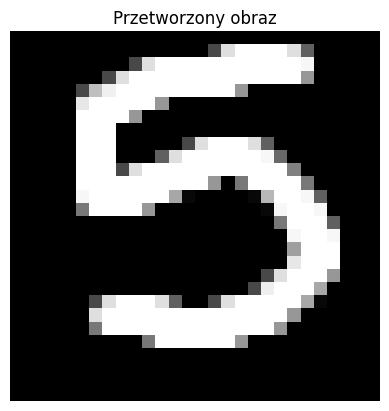

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 5, Prawdopodobieństwo: 0.9996
2. Cyfra: 8, Prawdopodobieństwo: 0.0003
3. Cyfra: 3, Prawdopodobieństwo: 0.0001


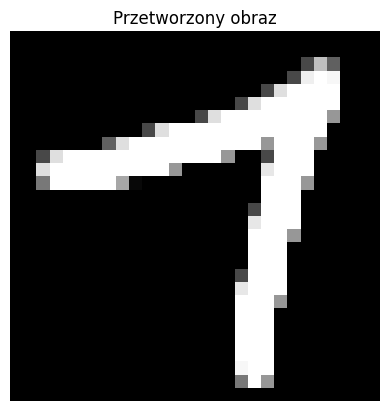

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 7, Prawdopodobieństwo: 0.9999
2. Cyfra: 1, Prawdopodobieństwo: 0.0000
3. Cyfra: 9, Prawdopodobieństwo: 0.0000


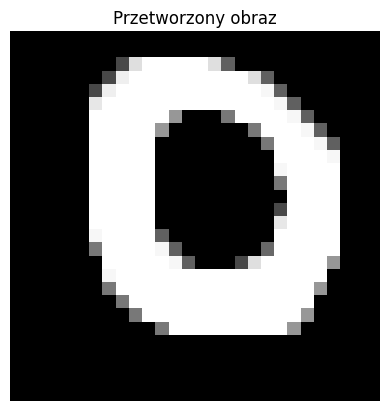

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 0, Prawdopodobieństwo: 0.9991
2. Cyfra: 6, Prawdopodobieństwo: 0.0009
3. Cyfra: 2, Prawdopodobieństwo: 0.0000


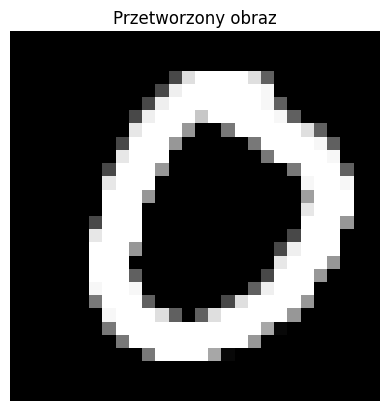

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 0, Prawdopodobieństwo: 1.0000
2. Cyfra: 6, Prawdopodobieństwo: 0.0000
3. Cyfra: 8, Prawdopodobieństwo: 0.0000


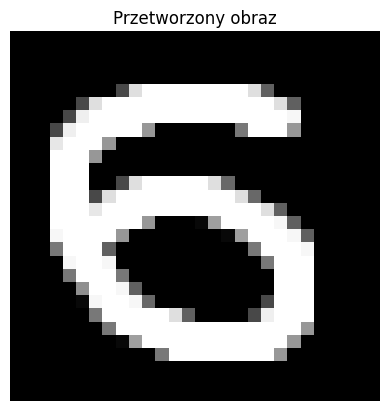

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Top 3 rozpoznane cyfry:
1. Cyfra: 6, Prawdopodobieństwo: 0.6713
2. Cyfra: 5, Prawdopodobieństwo: 0.3088
3. Cyfra: 8, Prawdopodobieństwo: 0.0197

--- Sprawdzenie 10 grafik z wyciętego zbioru testowego ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


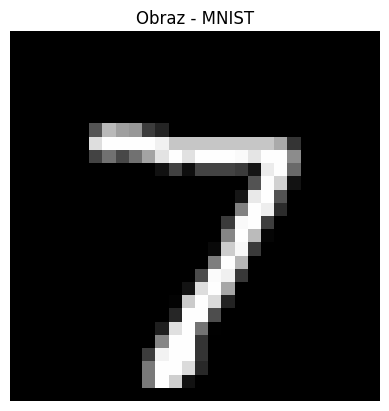

Top 3 rozpoznane cyfry:
1. Cyfra: 7, Prawdopodobieństwo: 1.0000
2. Cyfra: 2, Prawdopodobieństwo: 0.0000
3. Cyfra: 3, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


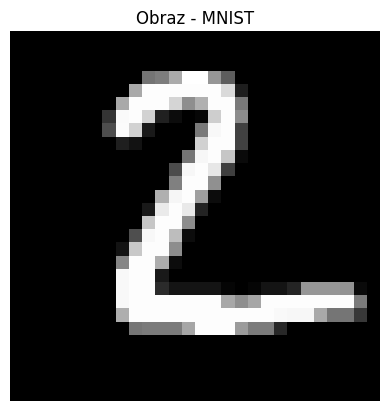

Top 3 rozpoznane cyfry:
1. Cyfra: 2, Prawdopodobieństwo: 1.0000
2. Cyfra: 1, Prawdopodobieństwo: 0.0000
3. Cyfra: 6, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


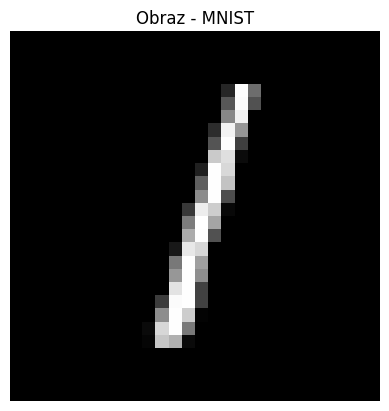

Top 3 rozpoznane cyfry:
1. Cyfra: 1, Prawdopodobieństwo: 1.0000
2. Cyfra: 7, Prawdopodobieństwo: 0.0000
3. Cyfra: 6, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


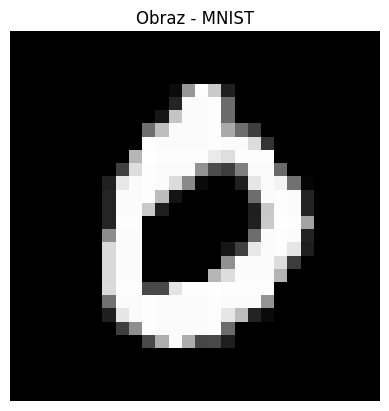

Top 3 rozpoznane cyfry:
1. Cyfra: 0, Prawdopodobieństwo: 1.0000
2. Cyfra: 6, Prawdopodobieństwo: 0.0000
3. Cyfra: 8, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


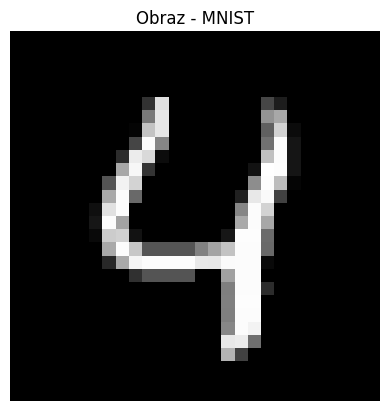

Top 3 rozpoznane cyfry:
1. Cyfra: 4, Prawdopodobieństwo: 0.9988
2. Cyfra: 9, Prawdopodobieństwo: 0.0012
3. Cyfra: 0, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


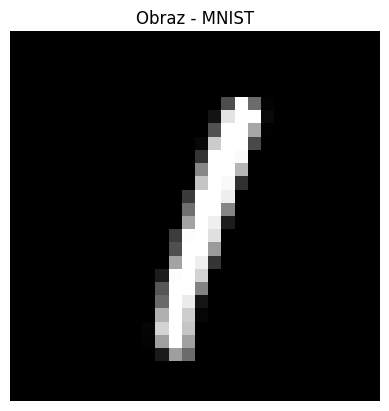

Top 3 rozpoznane cyfry:
1. Cyfra: 1, Prawdopodobieństwo: 1.0000
2. Cyfra: 7, Prawdopodobieństwo: 0.0000
3. Cyfra: 4, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


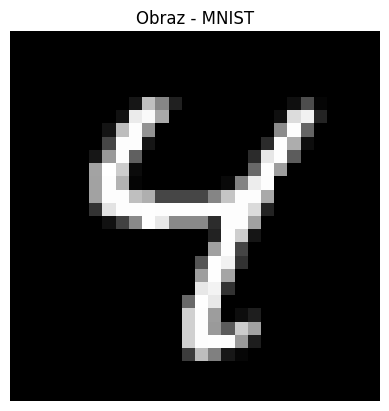

Top 3 rozpoznane cyfry:
1. Cyfra: 4, Prawdopodobieństwo: 0.9828
2. Cyfra: 8, Prawdopodobieństwo: 0.0099
3. Cyfra: 9, Prawdopodobieństwo: 0.0072
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


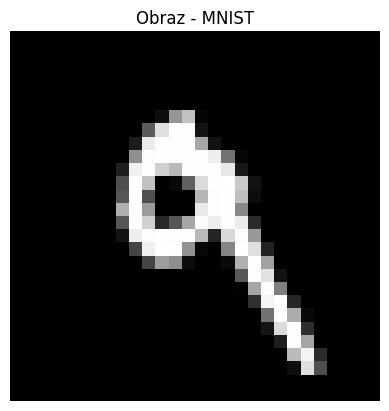

Top 3 rozpoznane cyfry:
1. Cyfra: 9, Prawdopodobieństwo: 0.9999
2. Cyfra: 4, Prawdopodobieństwo: 0.0001
3. Cyfra: 8, Prawdopodobieństwo: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


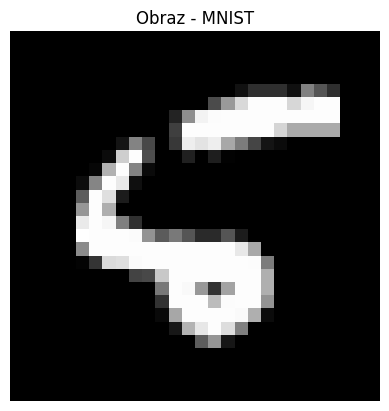

Top 3 rozpoznane cyfry:
1. Cyfra: 6, Prawdopodobieństwo: 0.6912
2. Cyfra: 5, Prawdopodobieństwo: 0.3049
3. Cyfra: 8, Prawdopodobieństwo: 0.0029
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


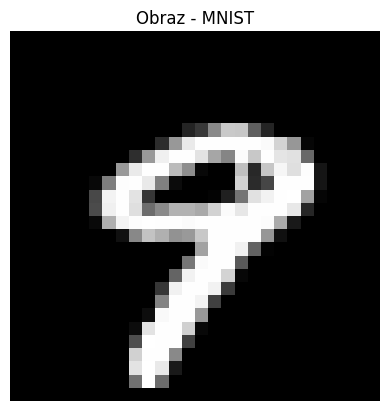

Top 3 rozpoznane cyfry:
1. Cyfra: 9, Prawdopodobieństwo: 1.0000
2. Cyfra: 4, Prawdopodobieństwo: 0.0000
3. Cyfra: 7, Prawdopodobieństwo: 0.0000


In [ ]:
#Wyświetlanie 3 najbardziej prawdopodobnych wyników, wraz z prawdopodobieństwem
from pathlib import Path
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import numpy as np

# Testowanie grafik z folderu
for path in Path("testowe").rglob("*.png"):
    image = Image.open(path).convert('L')
    image = ImageOps.invert(image)
    image = image.resize((28, 28))
    image = np.array(image).reshape(1, 28, 28, 1) / 255.0

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title('Przetworzony obraz')
    plt.axis('off')
    plt.show()

    prediction = model.predict(image)[0]
    top3_indices = np.argsort(prediction)[-3:][::-1]
    top3_probs = prediction[top3_indices]

    print("Top 3 rozpoznane cyfry:")
    for i, (label, prob) in enumerate(zip(top3_indices, top3_probs), 1):
        print(f"{i}. Cyfra: {label}, Prawdopodobieństwo: {prob:.4f}")

# Testowanie 10 wyciętych obrazów z MNIST

print("\n--- Sprawdzenie 10 grafik z wyciętego zbioru testowego ---")
for i, image in enumerate(images_to_check):
    image_input = image.reshape(1, 28, 28, 1)
    prediction = model.predict(image_input)[0]

    top3_indices = np.argsort(prediction)[-3:][::-1]
    top3_probs = prediction[top3_indices]

    true_label = np.argmax(labels_to_check[i])

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Obraz - MNIST")
    plt.axis('off')
    plt.show()

    print("Top 3 rozpoznane cyfry:")
    for j, (label, prob) in enumerate(zip(top3_indices, top3_probs), 1):
        print(f"{j}. Cyfra: {label}, Prawdopodobieństwo: {prob:.4f}")
